# Gull Aircraft Strike Analysis

This notebook provides a detailed analysis of gull-related aircraft strikes, examining:
- Flight phases when gulls strike most
- Geographic distribution (states)
- Aircraft components most frequently damaged
- Damage severity and patterns

In [60]:
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Setup data path
DATA_DIR = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path.cwd() / "data"
csv_path = DATA_DIR / "wildlife-strikes" / "database.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Expected dataset at {csv_path}. Run notebooks/download_wildlife.ipynb first.")

print(f"Data path: {csv_path}")

Data path: /mnt/c/Users/Pritam/Documents/ISI_inference/data/wildlife-strikes/database.csv


## Load and Filter Gull Data

In [61]:
# Load the full dataset
lazy_df = pl.scan_csv(
    csv_path,
    ignore_errors=True,
    infer_schema_length=2000,
    null_values=["", " ", "NA", "UNKNOWN"],
)

# Add damage flag
damage_lazy = lazy_df.with_columns(
    pl.col("Aircraft Damage")
    .cast(pl.Float64, strict=False)
    .fill_null(0)
    .clip(0, 1)
    .alias("damage_flag")
)

# Filter for gull species (case-insensitive)
gull_df = (
    damage_lazy
    .filter(
        pl.col("Species Name").str.to_lowercase().str.contains("gull")
    )
    .collect()
)

print(f"Total gull-related strikes: {len(gull_df):,}")
print(f"Overall damage rate for gulls: {gull_df['damage_flag'].mean():.2%}")

Total gull-related strikes: 10,584
Overall damage rate for gulls: 13.73%


## Gull Species Breakdown

/tmp/ipykernel_302893/114620481.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


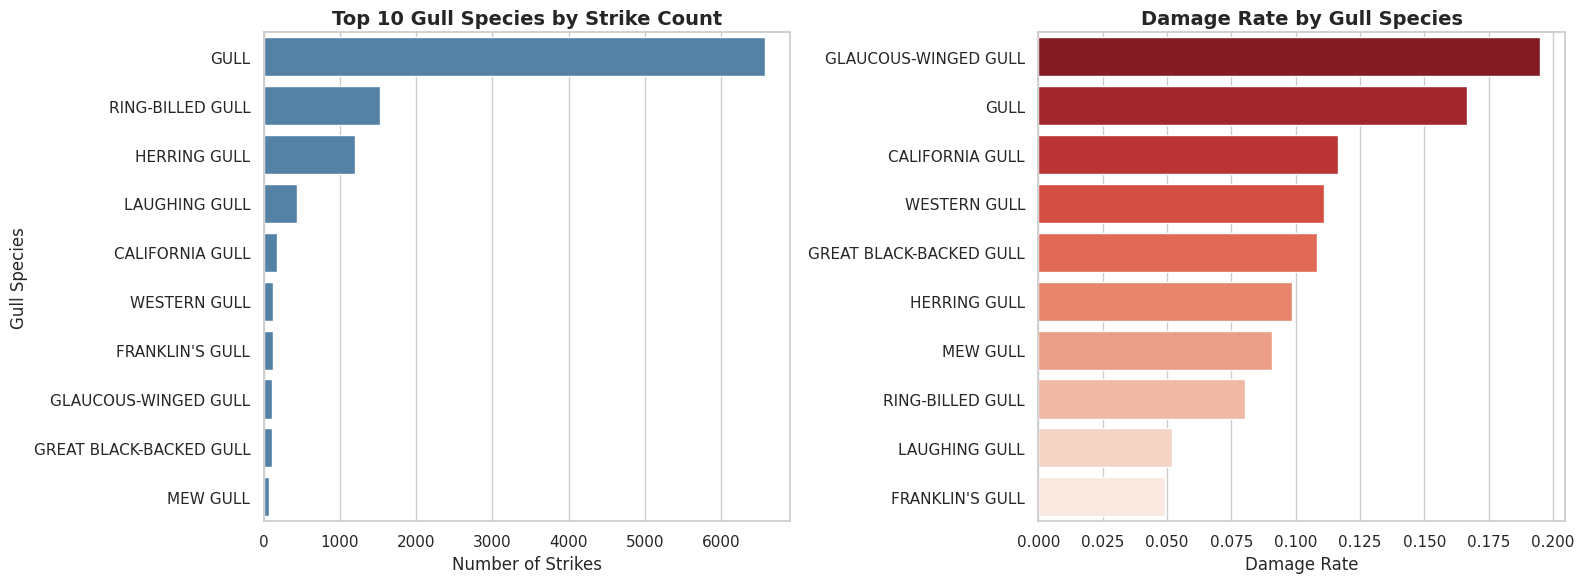

,Species Name,strike_count,damage_rate
0,GULL,6580,0.166413
1,RING-BILLED GULL,1531,0.080340
2,HERRING GULL,1199,0.098415
3,LAUGHING GULL,443,0.051919
4,CALIFORNIA GULL,172,0.116279
5,WESTERN GULL,126,0.111111
6,FRANKLIN'S GULL,122,0.049180
7,GLAUCOUS-WINGED GULL,118,0.194915
8,GREAT BLACK-BACKED GULL,111,0.108108
9,MEW GULL,66,0.090909


In [62]:
# Analyze different gull species
gull_species = (
    gull_df
    .group_by("Species Name")
    .agg([
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    ])
    .sort("strike_count", descending=True)
)

gull_species_pd = gull_species.to_pandas()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Strike count
sns.barplot(
    data=gull_species_pd.head(10),
    y="Species Name",
    x="strike_count",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Top 10 Gull Species by Strike Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Strikes")
axes[0].set_ylabel("Gull Species")

# Damage rate
sns.barplot(
    data=gull_species_pd.head(10).sort_values("damage_rate", ascending=False),
    y="Species Name",
    x="damage_rate",
    ax=axes[1],
    palette="Reds_r"
)
axes[1].set_title("Damage Rate by Gull Species", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Damage Rate")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

gull_species_pd

## Flight Phase Analysis

Which phase of flight do gulls most frequently strike aircraft?

/tmp/ipykernel_302893/2179123620.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


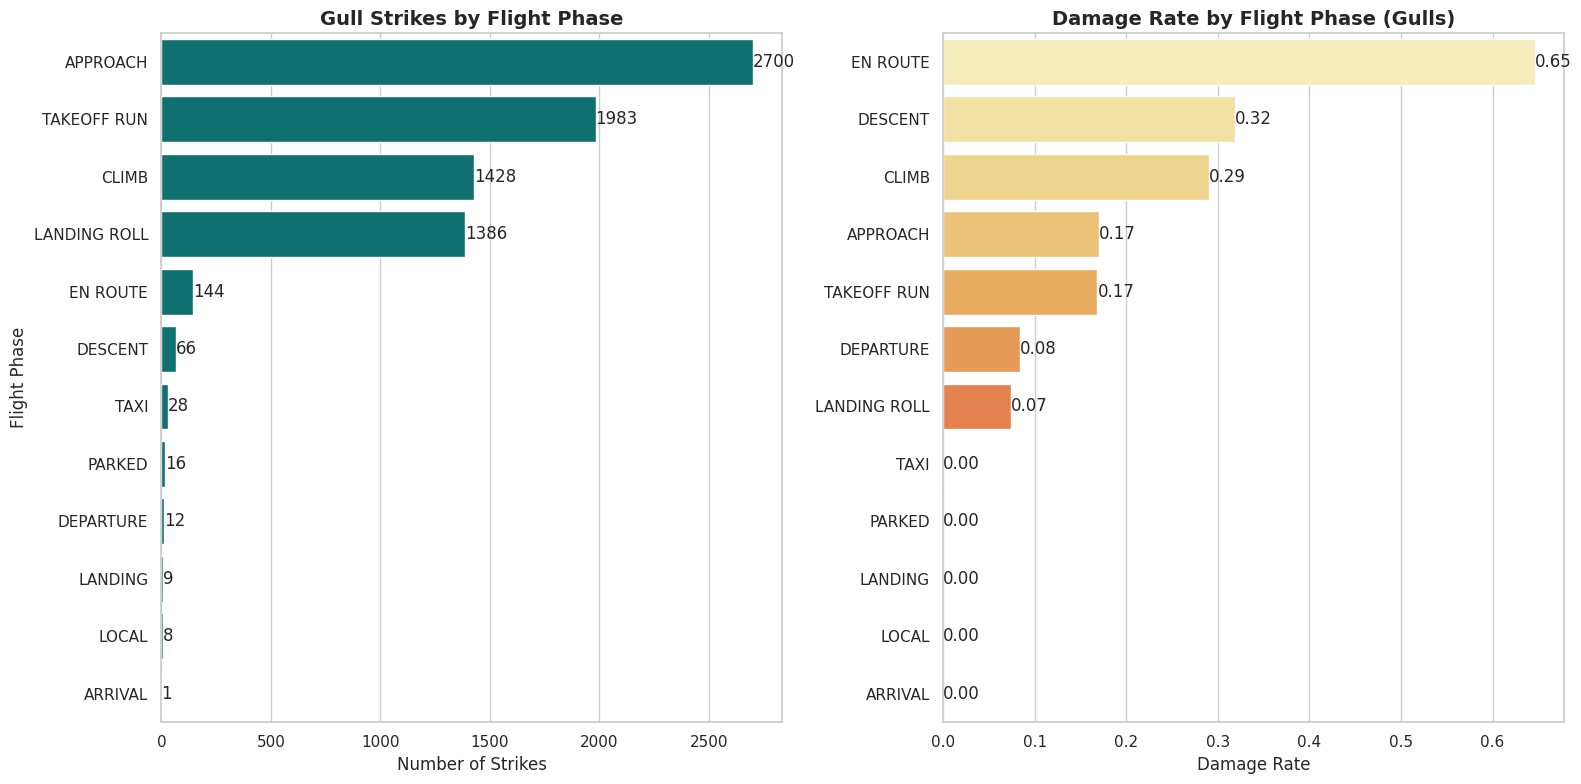


Flight Phase Summary:


,Flight Phase,strike_count,damage_rate,total_damage_events
0,APPROACH,2700,0.169630,458.0
1,TAKEOFF RUN,1983,0.168432,334.0
2,CLIMB,1428,0.289916,414.0
3,LANDING ROLL,1386,0.073593,102.0
4,EN ROUTE,144,0.645833,93.0
5,DESCENT,66,0.318182,21.0
6,TAXI,28,0.000000,0.0
7,PARKED,16,0.000000,0.0
8,DEPARTURE,12,0.083333,1.0
9,LANDING,9,0.000000,0.0


In [63]:
# Analyze flight phases
flight_phase = (
    gull_df
    .filter(pl.col("Flight Phase").is_not_null())
    .group_by("Flight Phase")
    .agg([
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
        pl.col("damage_flag").sum().alias("total_damage_events"),
    ])
    .sort("strike_count", descending=True)
)

flight_phase_pd = flight_phase.to_pandas()

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Strike count by phase
sns.barplot(
    data=flight_phase_pd,
    y="Flight Phase",
    x="strike_count",
    ax=axes[0],
    color="teal"
)
axes[0].set_title("Gull Strikes by Flight Phase", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Strikes")
axes[0].set_ylabel("Flight Phase")

# Add value labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Damage rate by phase
sns.barplot(
    data=flight_phase_pd.sort_values("damage_rate", ascending=False),
    y="Flight Phase",
    x="damage_rate",
    ax=axes[1],
    palette="YlOrRd"
)
axes[1].set_title("Damage Rate by Flight Phase (Gulls)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Damage Rate")
axes[1].set_ylabel("")

# Add percentage labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

print("\nFlight Phase Summary:")
flight_phase_pd

## Geographic Distribution (State Analysis)

Which states experience the most gull strikes?

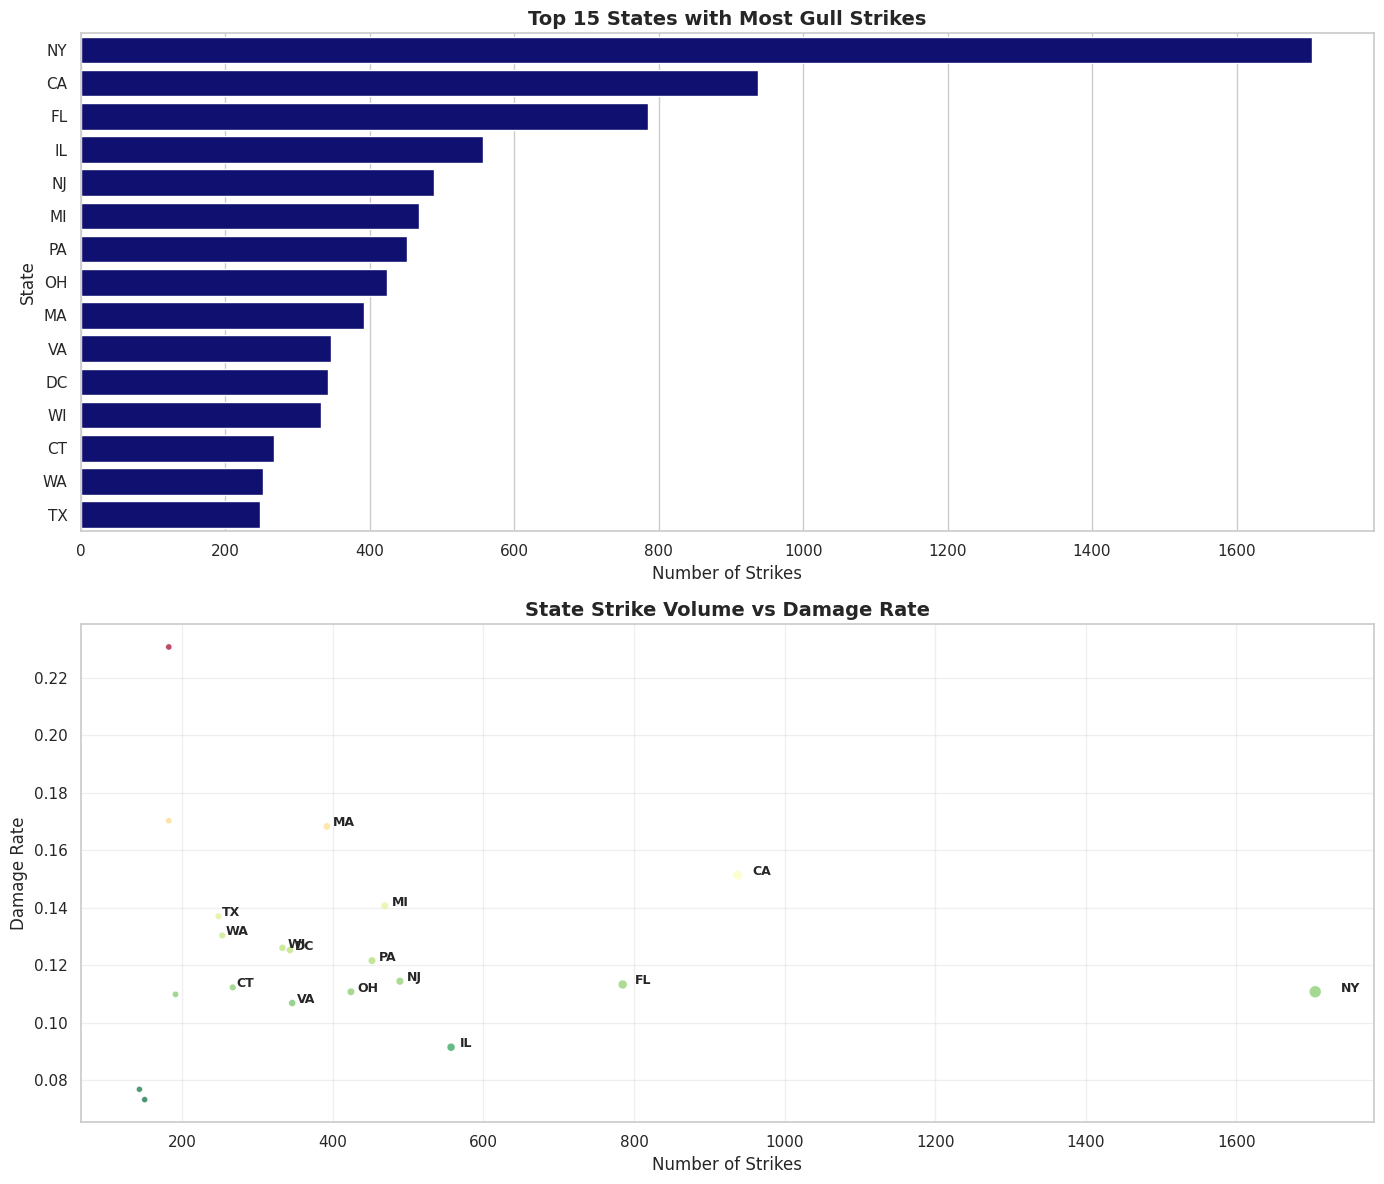


Top 20 States Summary:


,State,strike_count,damage_rate,total_damage_events
0,NY,1705,0.110850,189.0
1,CA,938,0.151386,142.0
2,FL,785,0.113376,89.0
3,IL,557,0.091562,51.0
4,NJ,489,0.114519,56.0
5,MI,469,0.140725,66.0
6,PA,452,0.121681,55.0
7,OH,424,0.110849,47.0
8,MA,392,0.168367,66.0
9,VA,346,0.106936,37.0


In [64]:
# Analyze by state
state_analysis = (
    gull_df
    .filter(pl.col("State").is_not_null())
    .group_by("State")
    .agg([
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
        pl.col("damage_flag").sum().alias("total_damage_events"),
    ])
    .sort("strike_count", descending=True)
    .head(20)
)

state_pd = state_analysis.to_pandas()

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top states by strike count
sns.barplot(
    data=state_pd.head(15),
    x="strike_count",
    y="State",
    ax=axes[0],
    color="navy"
)
axes[0].set_title("Top 15 States with Most Gull Strikes", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Strikes")
axes[0].set_ylabel("State")

# Scatter plot: strike count vs damage rate
sns.scatterplot(
    data=state_pd,
    x="strike_count",
    y="damage_rate",
    size="strike_count",
    hue="damage_rate",
    palette="RdYlGn_r",
    ax=axes[1],
    s=200,
    alpha=0.7,
    legend=False
)

# Add state labels
for _, row in state_pd.head(15).iterrows():
    axes[1].text(
        row["strike_count"] * 1.02,
        row["damage_rate"],
        row["State"],
        fontsize=9,
        fontweight="bold"
    )

axes[1].set_title("State Strike Volume vs Damage Rate", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Number of Strikes")
axes[1].set_ylabel("Damage Rate")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 20 States Summary:")
state_pd

## Species–State Interaction
Identify which gull species dominate in each state and how often those pairings result in damage events.

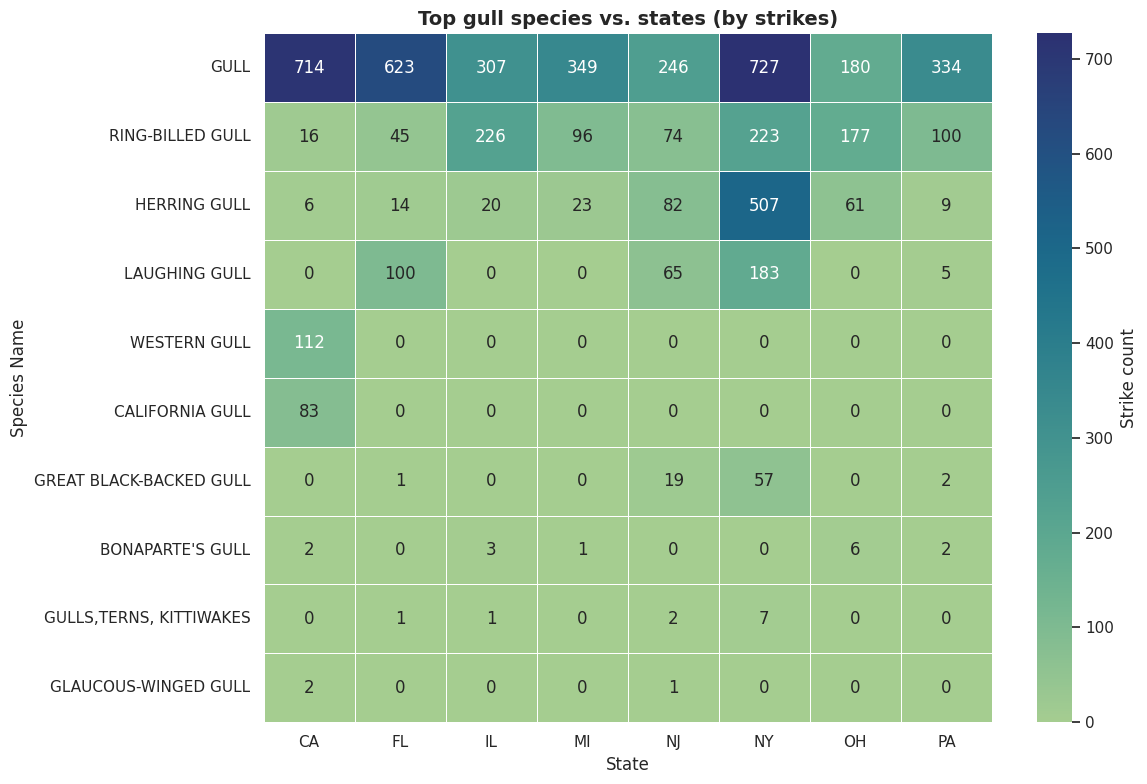

,State,Species Name,strike_count,damage_events,damage_rate
1,CA,GULL,714,121.0,0.169468
0,NY,GULL,727,107.0,0.147180
2,FL,GULL,623,77.0,0.123596
4,MI,GULL,349,54.0,0.154728
11,MA,GULL,221,53.0,0.239819
3,NY,HERRING GULL,507,52.0,0.102564
5,PA,GULL,334,46.0,0.137725
6,IL,GULL,307,43.0,0.140065
8,NJ,GULL,246,42.0,0.170732
13,OH,GULL,180,37.0,0.205556


In [65]:
species_state = (
    gull_df
    .filter(pl.col("State").is_not_null() & pl.col("Species Name").is_not_null())
    .group_by(["State", "Species Name"])
    .agg([
        pl.len().alias("strike_count"),
        pl.col("damage_flag").sum().alias("damage_events"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    ])
    .sort("strike_count", descending=True)
 )
species_state_pd = species_state.to_pandas()
if "state_pd" in globals():
    top_state_list = state_pd["State"].head(8).tolist()
else:
    top_state_list = (
        species_state_pd.groupby("State")["strike_count"].sum().sort_values(ascending=False).head(8).index.tolist()
    )
subset = species_state_pd[species_state_pd["State"].isin(top_state_list)].copy()
heatmap_counts = subset.pivot_table(
    index="Species Name",
    columns="State",
    values="strike_count",
    aggfunc="sum",
    fill_value=0
)
heatmap_counts = heatmap_counts.loc[
    heatmap_counts.sum(axis=1).sort_values(ascending=False).index
]
top_heatmap = heatmap_counts.head(10)
plt.figure(figsize=(12, 8))
sns.heatmap(
    top_heatmap,
    annot=True,
    fmt=".0f",
    cmap="crest",
    linewidths=0.4,
    cbar_kws={"label": "Strike count"}
)
plt.title("Top gull species vs. states (by strikes)", fontsize=14, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Species Name")
plt.tight_layout()
plt.show()
top_damage_pairs = (
    species_state_pd[species_state_pd["strike_count"] >= 20]
    .sort_values(["damage_events", "strike_count"], ascending=False)
    .head(10)
)
top_damage_pairs

## Aircraft Component Damage Analysis

Which parts of the aircraft do gulls damage most frequently?

In [66]:
# Define aircraft component columns
component_pairs = [
    ("Radome Strike", "Radome Damage"),
    ("Windshield Strike", "Windshield Damage"),
    ("Nose Strike", "Nose Damage"),
    ("Engine1 Strike", "Engine1 Damage"),
    ("Engine2 Strike", "Engine2 Damage"),
    ("Propeller Strike", "Propeller Damage"),
    ("Wing or Rotor Strike", "Wing or Rotor Damage"),
    ("Fuselage Strike", "Fuselage Damage"),
    ("Landing Gear Strike", "Landing Gear Damage"),
    ("Tail Strike", "Tail Damage"),
    ("Lights Strike", "Lights Damage"),
    ("Other Strike", "Other Damage"),
]

# Calculate statistics for each component
component_stats = []

for strike_col, damage_col in component_pairs:
    component_name = strike_col.replace(" Strike", "").replace("1", "").replace("2", "")

    # Convert to pandas for easier analysis
    gull_pd = gull_df.to_pandas()

    strikes = gull_pd[strike_col].fillna(0).sum()
    damages = gull_pd[damage_col].fillna(0).sum()
    damage_rate = damages / strikes if strikes > 0 else 0

    component_stats.append({
        "Component": component_name,
        "Total Strikes": int(strikes),
        "Total Damages": int(damages),
        "Damage Rate": damage_rate
    })

component_df = pd.DataFrame(component_stats).sort_values("Total Strikes", ascending=False)

# Filter out components with no strikes
component_df = component_df[component_df["Total Strikes"] > 0]

print("Aircraft Component Damage Summary:")
component_df

Aircraft Component Damage Summary:


,Component,Total Strikes,Total Damages,Damage Rate
6,Wing or Rotor,1528,361,0.236257
2,Nose,1022,92,0.090020
1,Windshield,976,87,0.089139
7,Fuselage,901,45,0.049945
11,Other,860,146,0.169767
3,Engine,799,289,0.361702
8,Landing Gear,732,57,0.077869
0,Radome,728,156,0.214286
4,Engine,666,265,0.397898
5,Propeller,383,36,0.093995


/tmp/ipykernel_302893/1328739608.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


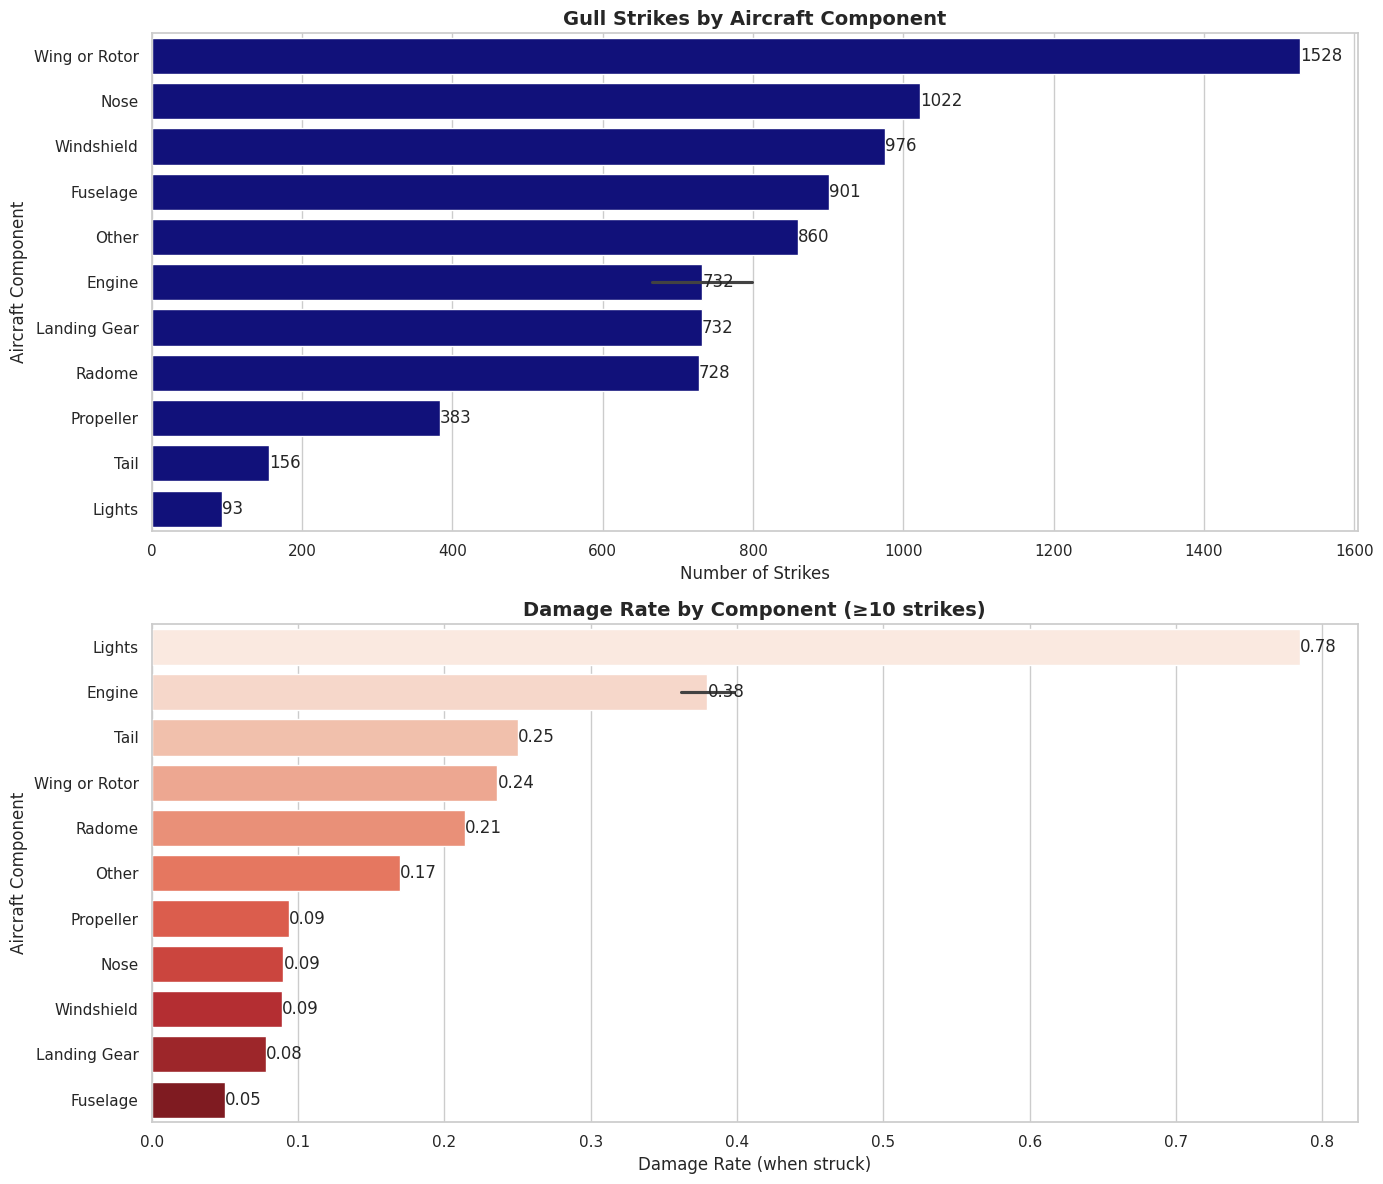

In [67]:
# Visualize component damage
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Strike frequency by component
sns.barplot(
    data=component_df,
    x="Total Strikes",
    y="Component",
    ax=axes[0],
    color="darkblue"
)
axes[0].set_title("Gull Strikes by Aircraft Component", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Strikes")
axes[0].set_ylabel("Aircraft Component")

# Add value labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Damage rate by component
component_damage_sorted = component_df[component_df["Total Strikes"] >= 10].sort_values("Damage Rate", ascending=False)

sns.barplot(
    data=component_damage_sorted,
    x="Damage Rate",
    y="Component",
    ax=axes[1],
    palette="Reds"
)
axes[1].set_title("Damage Rate by Component (≥10 strikes)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Damage Rate (when struck)")
axes[1].set_ylabel("Aircraft Component")

# Add percentage labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

## Combined Analysis: State, Phase, and Component

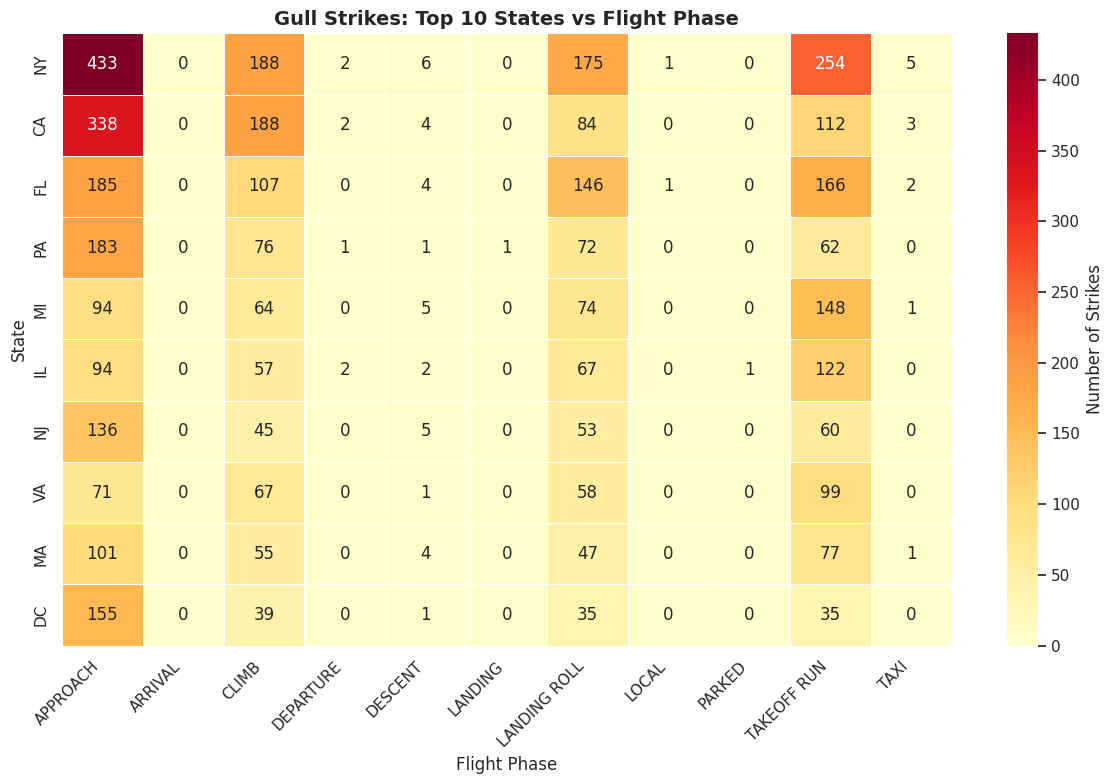


State-Phase Cross-tabulation (Top 10 States):


Flight Phase,APPROACH,ARRIVAL,CLIMB,DEPARTURE,DESCENT,LANDING,LANDING ROLL,LOCAL,PARKED,TAKEOFF RUN,TAXI
State,,,,,,,,,,,
NY,433,0,188,2,6,0,175,1,0,254,5
CA,338,0,188,2,4,0,84,0,0,112,3
FL,185,0,107,0,4,0,146,1,0,166,2
PA,183,0,76,1,1,1,72,0,0,62,0
MI,94,0,64,0,5,0,74,0,0,148,1
IL,94,0,57,2,2,0,67,0,1,122,0
NJ,136,0,45,0,5,0,53,0,0,60,0
VA,71,0,67,0,1,0,58,0,0,99,0
MA,101,0,55,0,4,0,47,0,0,77,1


In [68]:
# Cross-tabulation: Top states and flight phases
gull_pd = gull_df.to_pandas()

state_phase_crosstab = pd.crosstab(
    gull_pd["State"],
    gull_pd["Flight Phase"],
    margins=True
)

# Get top 10 states
top_states = state_phase_crosstab.iloc[:-1, -1].nlargest(10).index
state_phase_top = state_phase_crosstab.loc[top_states, state_phase_crosstab.columns[:-1]]

# Visualize heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    state_phase_top,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Number of Strikes"}
)
plt.title("Gull Strikes: Top 10 States vs Flight Phase", fontsize=14, fontweight="bold")
plt.xlabel("Flight Phase")
plt.ylabel("State")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nState-Phase Cross-tabulation (Top 10 States):")
state_phase_top

## Temporal Analysis

When do gull strikes occur most frequently?

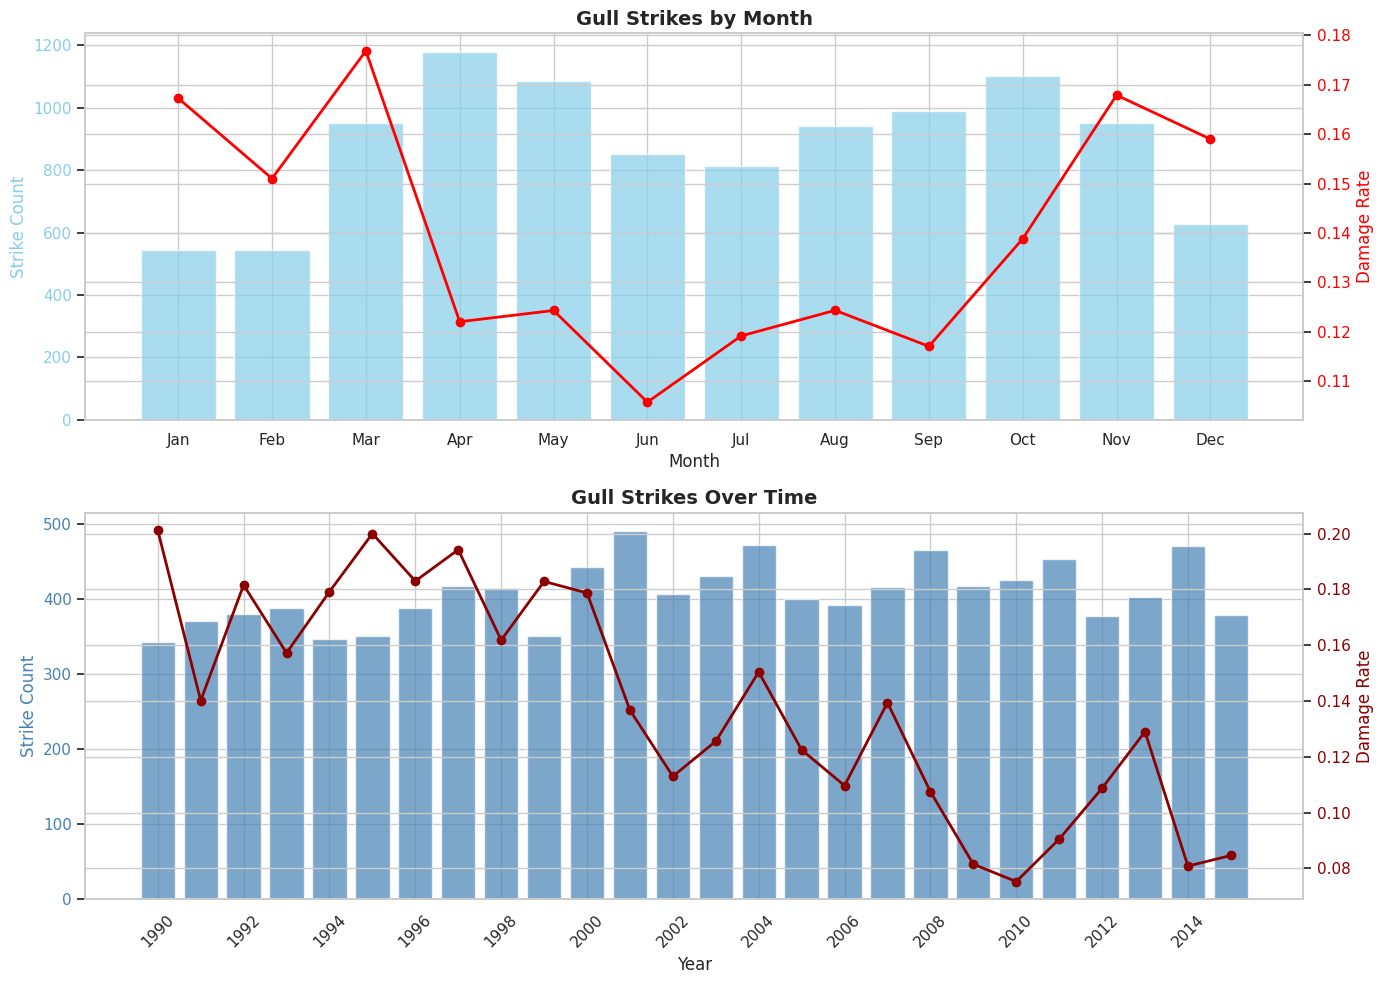

In [69]:
# Monthly distribution
monthly_strikes = (
    gull_df
    .filter(pl.col("Incident Month").is_not_null())
    .group_by("Incident Month")
    .agg([
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    ])
    .sort("Incident Month")
    .to_pandas()
)

# Add month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_strikes['Month Name'] = monthly_strikes['Incident Month'].apply(lambda x: month_names[int(x)-1] if 1 <= x <= 12 else 'Unknown')

# Yearly trend
yearly_strikes = (
    gull_df
    .filter(pl.col("Incident Year").is_not_null())
    .group_by("Incident Year")
    .agg([
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    ])
    .sort("Incident Year")
    .to_pandas()
)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly distribution
ax1 = axes[0]
ax1.bar(monthly_strikes['Month Name'], monthly_strikes['strike_count'], color='skyblue', alpha=0.7)
ax1.set_ylabel('Strike Count', color='skyblue', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_title('Gull Strikes by Month', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(monthly_strikes['Month Name'], monthly_strikes['damage_rate'], color='red', marker='o', linewidth=2)
ax2.set_ylabel('Damage Rate', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Yearly trend
ax3 = axes[1]
ax3.bar(yearly_strikes['Incident Year'], yearly_strikes['strike_count'], color='steelblue', alpha=0.7)
ax3.set_ylabel('Strike Count', color='steelblue', fontsize=12)
ax3.set_xlabel('Year', fontsize=12)
ax3.tick_params(axis='y', labelcolor='steelblue')
ax3.set_title('Gull Strikes Over Time', fontsize=14, fontweight='bold')
ax3.set_xticks(yearly_strikes['Incident Year'][::2])
ax3.tick_params(axis='x', rotation=45)

ax4 = ax3.twinx()
ax4.plot(yearly_strikes['Incident Year'], yearly_strikes['damage_rate'], color='darkred', marker='o', linewidth=2)
ax4.set_ylabel('Damage Rate', color='darkred', fontsize=12)
ax4.tick_params(axis='y', labelcolor='darkred')

plt.tight_layout()
plt.show()

## Key Findings Summary

In [70]:
# Generate summary statistics
print("=" * 80)
print("GULL AIRCRAFT STRIKE ANALYSIS - KEY FINDINGS")
print("=" * 80)

print(f"\n1. OVERALL STATISTICS")
print(f"   - Total gull strikes: {len(gull_df):,}")
print(f"   - Overall damage rate: {gull_df['damage_flag'].mean():.2%}")

print(f"\n2. MOST DANGEROUS FLIGHT PHASE")
top_phase = flight_phase_pd.iloc[0]
print(f"   - Phase: {top_phase['Flight Phase']}")
print(f"   - Strikes: {top_phase['strike_count']:,}")
print(f"   - Damage rate: {top_phase['damage_rate']:.2%}")

print(f"\n3. HIGHEST DAMAGE RATE FLIGHT PHASE")
highest_damage_phase = flight_phase_pd.sort_values('damage_rate', ascending=False).iloc[0]
print(f"   - Phase: {highest_damage_phase['Flight Phase']}")
print(f"   - Damage rate: {highest_damage_phase['damage_rate']:.2%}")
print(f"   - Strikes: {highest_damage_phase['strike_count']:,}")

print(f"\n4. TOP STATE FOR GULL STRIKES")
top_state = state_pd.iloc[0]
print(f"   - State: {top_state['State']}")
print(f"   - Strikes: {top_state['strike_count']:,}")
print(f"   - Damage rate: {top_state['damage_rate']:.2%}")

print(f"\n5. MOST STRUCK AIRCRAFT COMPONENT")
top_component = component_df.iloc[0]
print(f"   - Component: {top_component['Component']}")
print(f"   - Strikes: {top_component['Total Strikes']:,}")
print(f"   - Damages: {top_component['Total Damages']:,}")
print(f"   - Damage rate: {top_component['Damage Rate']:.2%}")

print(f"\n6. HIGHEST DAMAGE RATE COMPONENT (≥10 strikes)")
if len(component_damage_sorted) > 0:
    highest_damage_comp = component_damage_sorted.iloc[0]
    print(f"   - Component: {highest_damage_comp['Component']}")
    print(f"   - Damage rate: {highest_damage_comp['Damage Rate']:.2%}")
    print(f"   - Strikes: {highest_damage_comp['Total Strikes']:,}")

print(f"\n7. SEASONAL PATTERN")
peak_month = monthly_strikes.loc[monthly_strikes['strike_count'].idxmax()]
print(f"   - Peak month: {peak_month['Month Name']}")
print(f"   - Strikes in peak month: {peak_month['strike_count']:,}")

print("\n" + "=" * 80)

GULL AIRCRAFT STRIKE ANALYSIS - KEY FINDINGS

1. OVERALL STATISTICS
   - Total gull strikes: 10,584
   - Overall damage rate: 13.73%

2. MOST DANGEROUS FLIGHT PHASE
   - Phase: APPROACH
   - Strikes: 2,700
   - Damage rate: 16.96%

3. HIGHEST DAMAGE RATE FLIGHT PHASE
   - Phase: EN ROUTE
   - Damage rate: 64.58%
   - Strikes: 144

4. TOP STATE FOR GULL STRIKES
   - State: NY
   - Strikes: 1,705
   - Damage rate: 11.09%

5. MOST STRUCK AIRCRAFT COMPONENT
   - Component: Wing or Rotor
   - Strikes: 1,528
   - Damages: 361
   - Damage rate: 23.63%

6. HIGHEST DAMAGE RATE COMPONENT (≥10 strikes)
   - Component: Lights
   - Damage rate: 78.49%
   - Strikes: 93

7. SEASONAL PATTERN
   - Peak month: Apr
   - Strikes in peak month: 1,180

